In [2]:
import pandas as pd
print("Pandas version:", pd.__version__)
print("Libraries loaded successfully!")

Pandas version: 2.3.2
Libraries loaded successfully!


In [16]:
import os
print(os.getcwd())

/drive


In [19]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (9994, 21)


In [20]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [21]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [22]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [23]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [24]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [25]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')

print(df[['Order Date', 'Order Year', 'Order Month', 'Order Month Name']].head())

  Order Date  Order Year  Order Month Order Month Name
0 2016-11-08        2016           11              Nov
1 2016-11-08        2016           11              Nov
2 2016-06-12        2016            6              Jun
3 2015-10-11        2015           10              Oct
4 2015-10-11        2015           10              Oct


In [26]:
print(df.shape)

(9994, 24)


In [27]:
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Order Date', 'Ship Date', 'Days to Ship']].head())

  Order Date  Ship Date  Days to Ship
0 2016-11-08 2016-11-11             3
1 2016-11-08 2016-11-11             3
2 2016-06-12 2016-06-16             4
3 2015-10-11 2015-10-18             7
4 2015-10-11 2015-10-18             7


In [28]:
df['High Discount Flag'] = df['Discount'] > 0.5

print(df[['Discount', 'High Discount Flag']].head(10))
print("\nTotal high discount rows:", df['High Discount Flag'].sum())

   Discount  High Discount Flag
0      0.00               False
1      0.00               False
2      0.00               False
3      0.45               False
4      0.20               False
5      0.00               False
6      0.00               False
7      0.20               False
8      0.20               False
9      0.00               False

Total high discount rows: 856


In [29]:
df.drop(columns=['Row ID', 'Country', 'Postal Code'], inplace=True)

print("Remaining columns:", df.columns.tolist())
print("New shape:", df.shape)

Remaining columns: ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month', 'Order Month Name', 'Days to Ship', 'High Discount Flag']
New shape: (9994, 23)


In [30]:
df['Sales'] = df['Sales'].round(2)
df['Profit'] = df['Profit'].round(2)

print(df[['Sales', 'Profit']].head())

    Sales  Profit
0  261.96   41.91
1  731.94  219.58
2   14.62    6.87
3  957.58 -383.03
4   22.37    2.52


In [31]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (9994, 23)

Missing values:
 Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Order Year            0
Order Month           0
Order Month Name      0
Days to Ship          0
High Discount Flag    0
dtype: int64

Data types:
 Order ID                      object
Order Date            datetime64[ns]
Ship Date             datetime64[ns]
Ship Mode                     object
Customer ID                   object
Customer Name                 object
Segment                       object
City                          object
State                         object
Region                        object
Product ID     

In [32]:
df.to_csv('superstore_clean.csv', index=False)
print("✅ Clean file saved as superstore_clean.csv!")

✅ Clean file saved as superstore_clean.csv!


In [2]:
import micropip
await micropip.install('seaborn')
print("Seaborn installed!")

Seaborn installed!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore_clean.csv')
print("Clean data loaded!")
print("Shape:", df.shape)

Clean data loaded!
Shape: (9994, 23)


In [4]:
total_sales = df['Sales'].sum().round(2)
total_profit = df['Profit'].sum().round(2)
total_orders = df['Order ID'].nunique()
profit_margin = round((total_profit / total_sales) * 100, 2)

print("💰 Total Revenue:    $", total_sales)
print("📈 Total Profit:     $", total_profit)
print("🛒 Total Orders:     ", total_orders)
print("📊 Profit Margin:    ", profit_margin, "%")

💰 Total Revenue:    $ 2297200.65
📈 Total Profit:     $ 286396.54
🛒 Total Orders:      5009
📊 Profit Margin:     12.47 %


In [5]:
category_performance = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)
print(category_performance)

                     Sales     Profit
Category                             
Furniture        741999.73   18451.10
Office Supplies  719046.90  122490.00
Technology       836154.02  145455.44


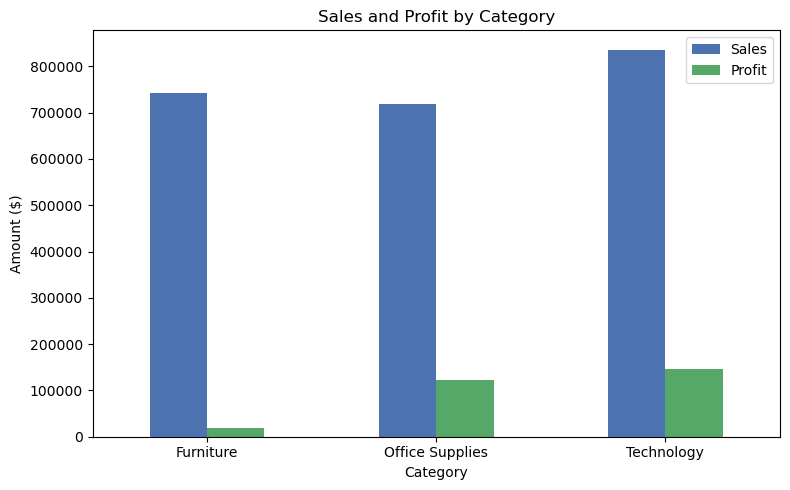

In [6]:
category_performance.plot(kind='bar', figsize=(8,5), color=['#4C72B0', '#55A868'])
plt.title('Sales and Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
region_performance = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
print(region_performance)

             Sales     Profit
Region                       
Central  501239.76   39706.24
East     678781.30   91522.50
South    391721.83   46749.49
West     725457.76  108418.31


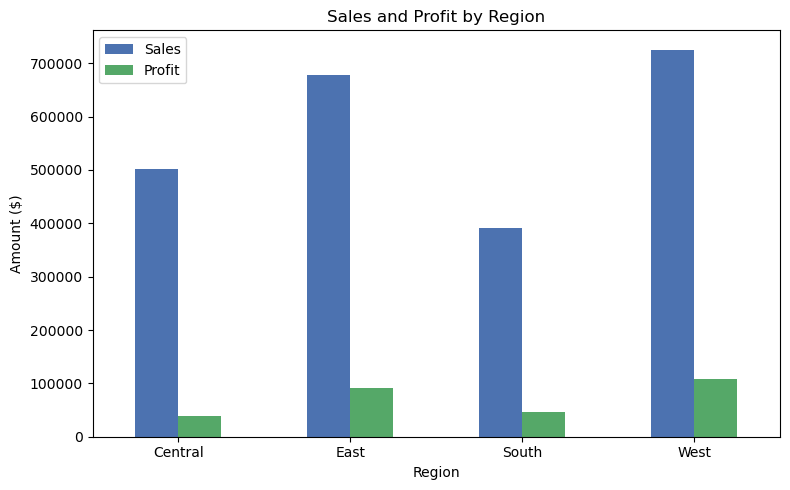

In [8]:
region_performance.plot(kind='bar', figsize=(8,5), color=['#4C72B0', '#55A868'])
plt.title('Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
yearly_sales = df.groupby('Order Year')['Sales'].sum().round(2)
print(yearly_sales)

Order Year
2014    484247.47
2015    470532.39
2016    609205.74
2017    733215.05
Name: Sales, dtype: float64


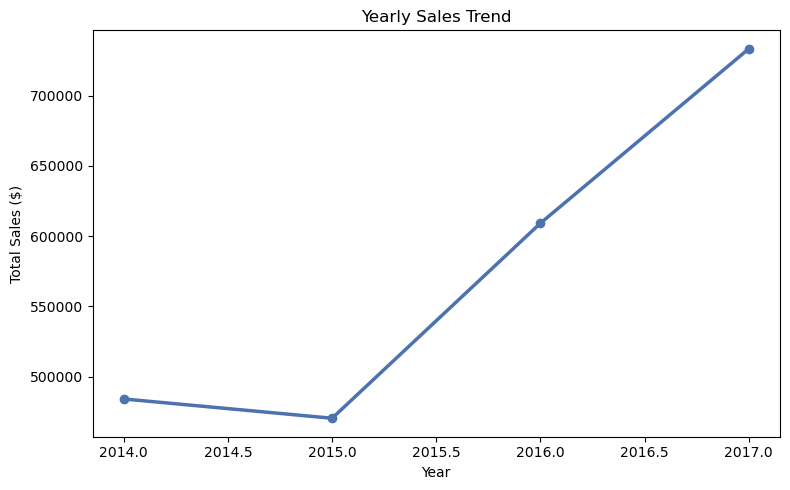

In [10]:
yearly_sales.plot(kind='line', figsize=(8,5), marker='o', color='#4C72B0', linewidth=2.5)
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

In [11]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().round(2).sort_values(ascending=False).head(10)
print(subcategory_sales)

Sub-Category
Phones         330007.10
Chairs         328449.10
Storage        223843.59
Tables         206965.53
Binders        203412.68
Machines       189238.60
Accessories    167380.31
Copiers        149528.01
Bookcases      114879.98
Appliances     107532.14
Name: Sales, dtype: float64


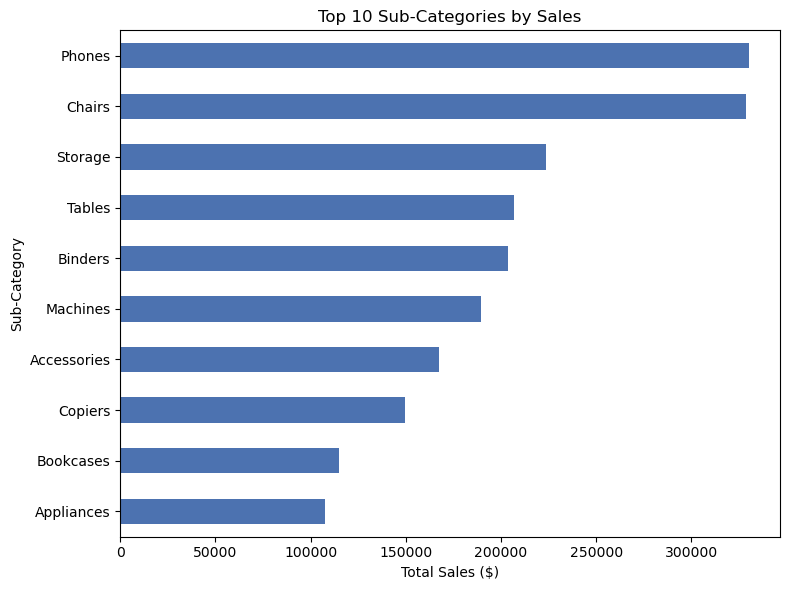

In [12]:
subcategory_sales.sort_values().plot(kind='barh', figsize=(8,6), color='#4C72B0')
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

In [13]:
discount_impact = df.groupby('High Discount Flag')['Profit'].mean().round(2)
print(discount_impact)


High Discount Flag
False    39.72
True    -89.44
Name: Profit, dtype: float64


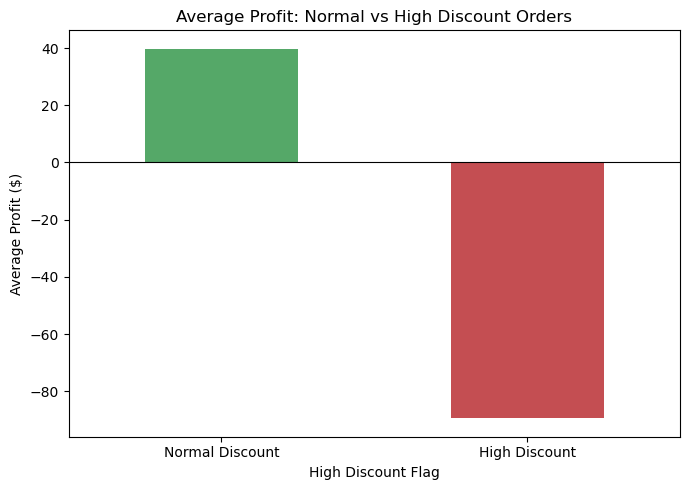

In [14]:
discount_impact.plot(kind='bar', figsize=(7,5), color=['#55A868', '#C44E52'])
plt.title('Average Profit: Normal vs High Discount Orders')
plt.xlabel('High Discount Flag')
plt.ylabel('Average Profit ($)')
plt.xticks(ticks=[0,1], labels=['Normal Discount', 'High Discount'], rotation=0)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [15]:
state_profit = df.groupby('State')['Profit'].sum().round(2).sort_values(ascending=False).head(10)
print(state_profit)

State
California    76381.23
New York      74038.47
Washington    33402.64
Michigan      24463.10
Virginia      18597.99
Indiana       18382.94
Georgia       16250.00
Kentucky      11199.66
Minnesota     10823.21
Delaware       9977.35
Name: Profit, dtype: float64


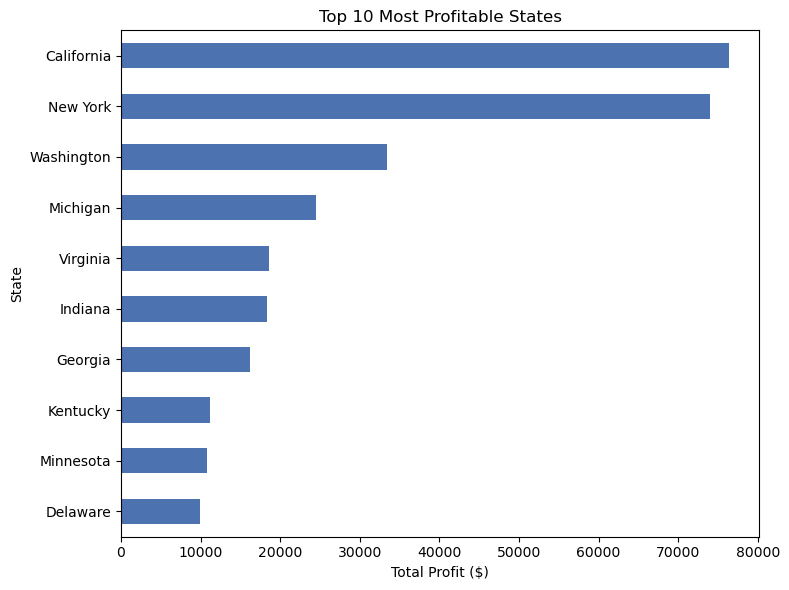

In [16]:
state_profit.sort_values().plot(kind='barh', figsize=(8,6), color='#4C72B0')
plt.title('Top 10 Most Profitable States')
plt.xlabel('Total Profit ($)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [17]:
segment_performance = df.groupby('Segment')[['Sales', 'Profit']].sum().round(2)
print(segment_performance)

                  Sales     Profit
Segment                           
Consumer     1161401.12  134118.64
Corporate     706146.32   91979.13
Home Office   429653.21   60298.77


In [18]:
segment_performance['Profit Margin %'] = ((segment_performance['Profit'] / segment_performance['Sales']) * 100).round(2)
print(segment_performance)

                  Sales     Profit  Profit Margin %
Segment                                            
Consumer     1161401.12  134118.64            11.55
Corporate     706146.32   91979.13            13.03
Home Office   429653.21   60298.77            14.03


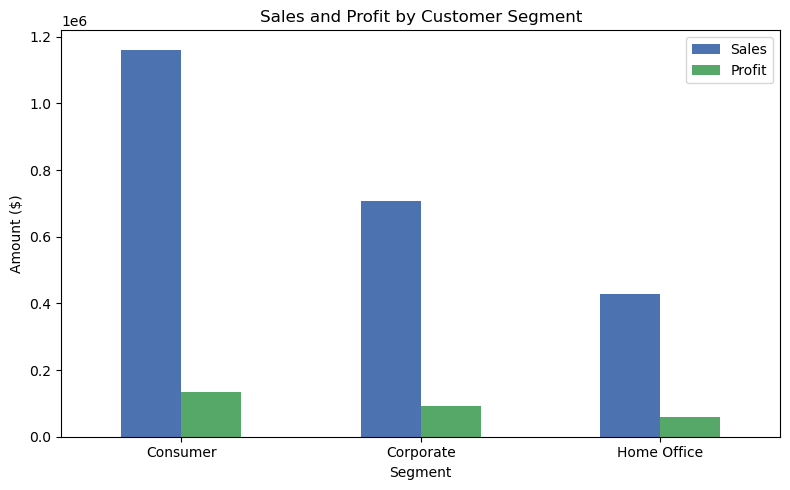

In [19]:
segment_performance[['Sales', 'Profit']].plot(kind='bar', figsize=(8,5), color=['#4C72B0', '#55A868'])
plt.title('Sales and Profit by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()